# **Heirarchical-Clustering**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.datasets import make_blobs

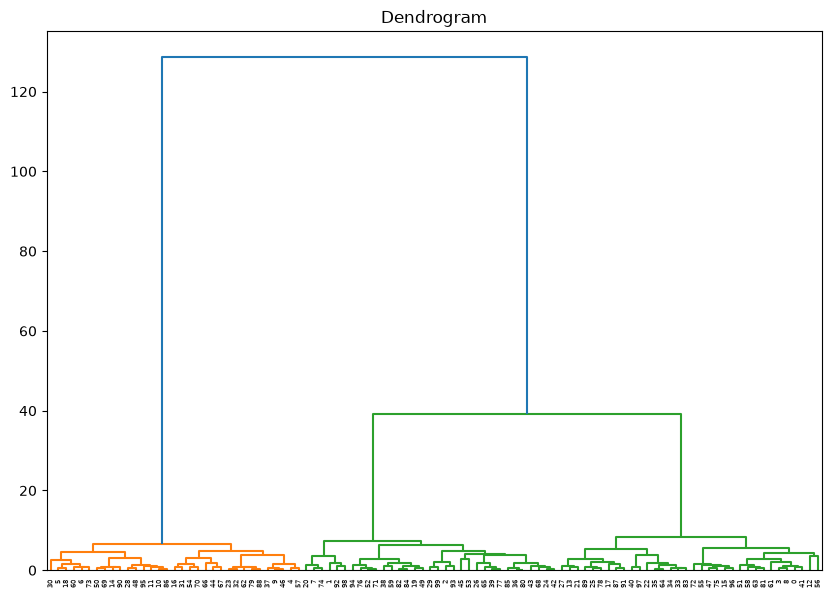

In [6]:
# Generate a random dataset with 100 samples and 3 features
X, y = make_blobs(n_samples=100, centers=3, n_features=3, random_state=42)

# perform heirarchical clustering with the AgglomerativeClustering Algorithms
clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clustering.fit(X)

# Plot th dendrogram.
plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.show()

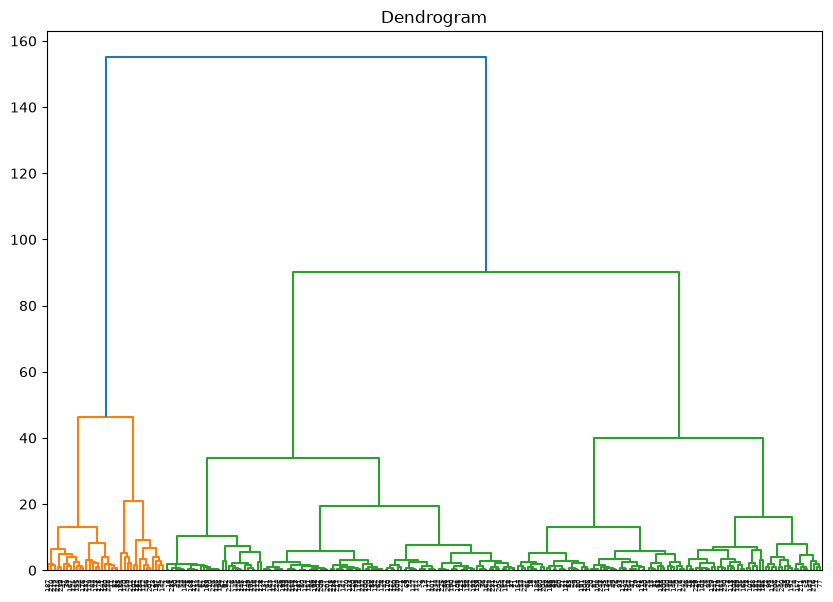

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.datasets import make_blobs

# load this dataset
df = sns.load_dataset('tips')

X = df[['total_bill', 'size', 'tip']].to_numpy()

# perform heirarchical clustering with the AgglomerativeClustering Algorithms
clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clustering.fit(X)

# Plot th dendrogram.
plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.show()

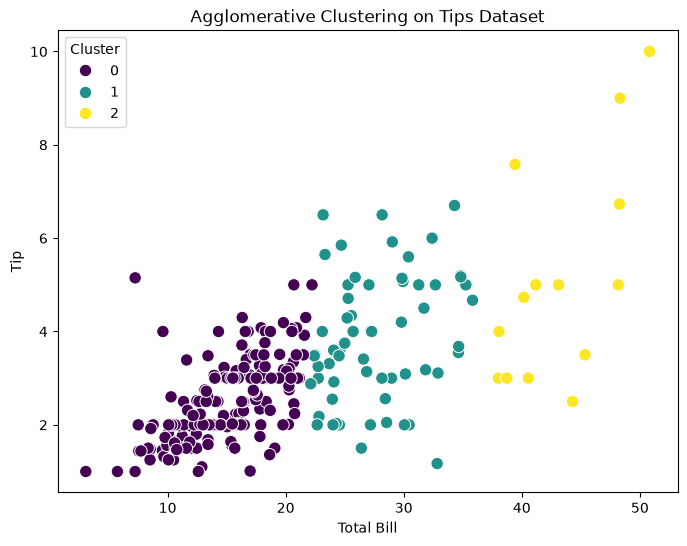

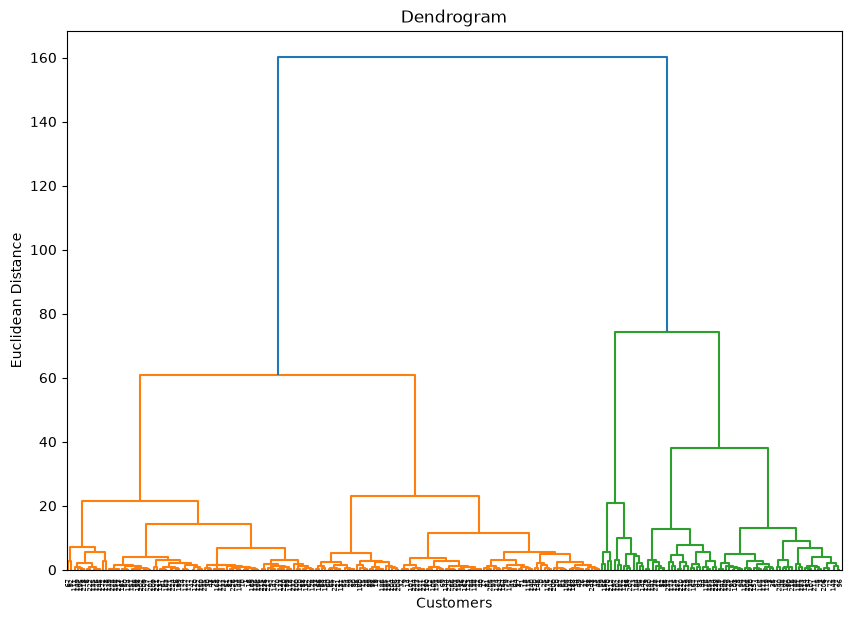

In [11]:
# Import required libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the tips dataset
tips = sns.load_dataset('tips')

# Select relevant features for clustering
features = ['total_bill', 'tip']

# Extract the selected features
X = tips[features]

# Perform Agglomerative Clustering

agg_clustering = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

# Fit the model and get cluster labels
agg_labels = agg_clustering.fit_predict(X)

# Add cluster labels to the dataset
tips['cluster'] = agg_labels

# -------------------------------
# Scatter Plot of Clusters

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='cluster', palette='viridis', s=80)
plt.title("Agglomerative Clustering on Tips Dataset")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend(title="Cluster")
plt.show()

# -------------------------------
# Dendrogram
# -------------------------------
plt.figure(figsize=(10, 7))
dendrogram(linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

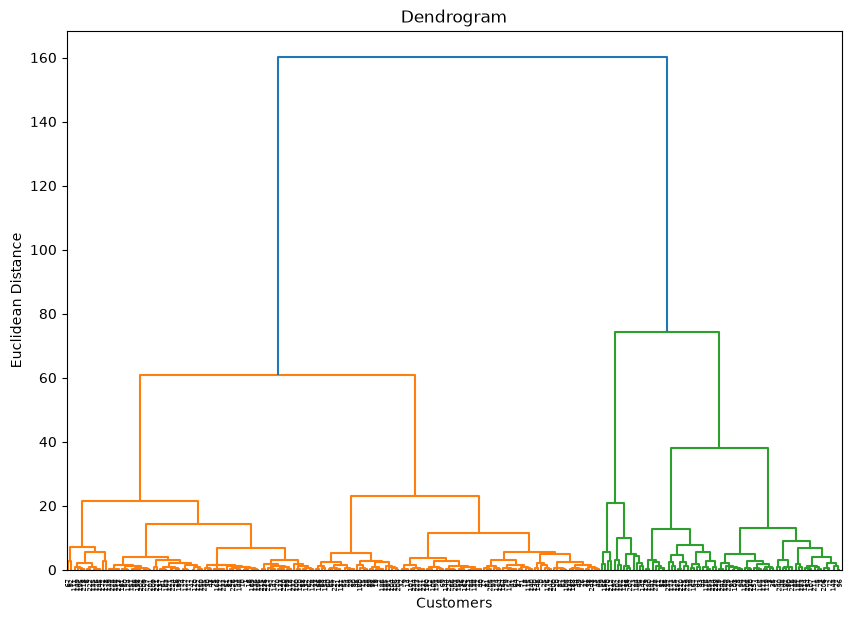

C:\Users\Zone Tech\AppData\Local\Temp\ipykernel_19232\1284735309.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


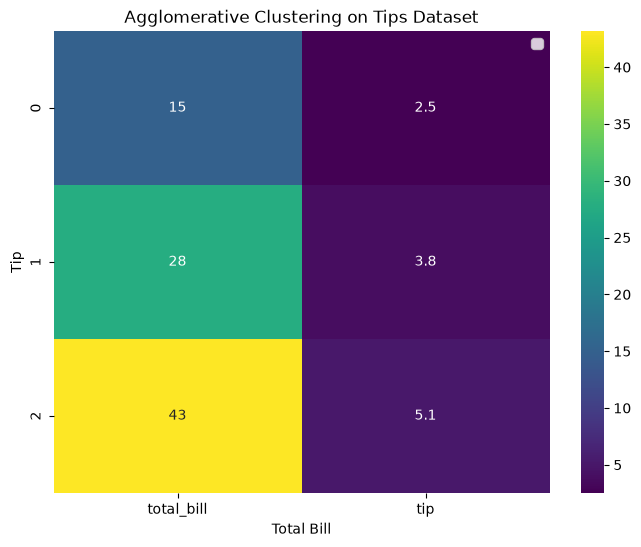

In [5]:
# Import required libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the tips dataset
tips = sns.load_dataset('tips')

# Select relevant features for clustering
features = ['total_bill', 'tip']

# Extract the selected features
X = tips[features]

# Perform Agglomerative Clustering

agg_clustering = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

# Fit the model and get cluster labels
agg_labels = agg_clustering.fit_predict(X)

# Add cluster labels to the dataset
tips['cluster'] = agg_labels

# -------------------------------
# Dendrogram
# -------------------------------
plt.figure(figsize=(10, 7))
dendrogram(linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

# heatmap Plot of Clusters

plt.figure(figsize=(8, 6))
cluster_summary = X.assign(cluster=agg_labels).groupby('cluster').mean()
sns.heatmap(cluster_summary, annot=True, cmap='viridis')
plt.title("Agglomerative Clustering on Tips Dataset")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()


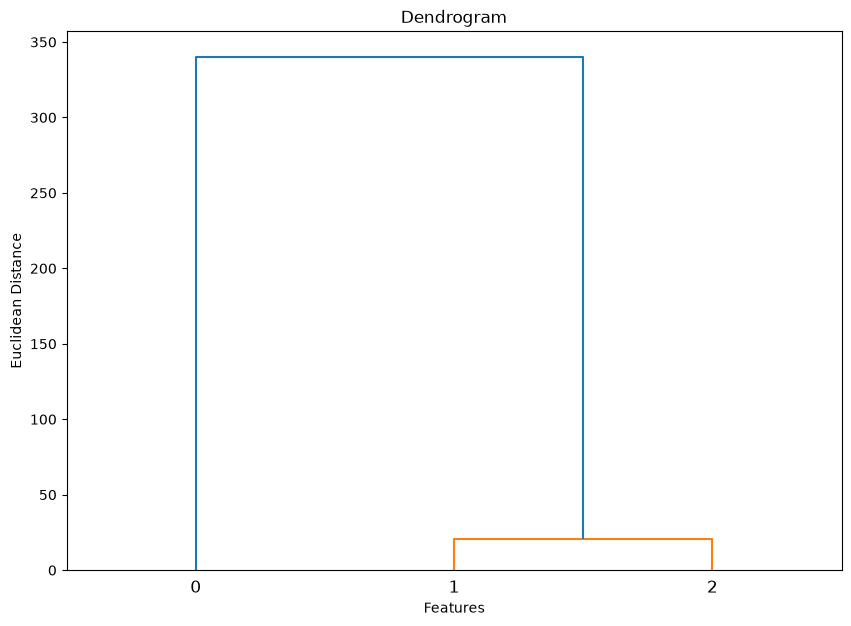

In [3]:
# Import required libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the tips dataset
tips = sns.load_dataset('tips')

# Select relevant features for clustering
features = ['total_bill', 'tip', 'size']

# Extract the selected features
X = tips[features]

# tranpose the data matrix
X_transposed = X.transpose()

# compute the linkage matrix
linkage_matrix = linkage(X_transposed, method='ward')

# -------------------------------
# Dendrogram
# -------------------------------
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram")
plt.xlabel("Features")
plt.ylabel("Euclidean Distance")
plt.show()


# Evaluation matrix

In [6]:
# 1. Silhouette Score
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
# Fit the clustering model on the current X and compute labels
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agg_labels = agg_clustering.fit_predict(X)

# Calculate Silhouette Score
silhouette = silhouette_score(X, agg_labels)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.5685


In [7]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

# Function to calculate Dunn Index
def dunn_index(X, labels):

    distances = squareform(pdist(X, metric='euclidean'))

    unique_clusters = np.unique(labels)

    # Maximum intra-cluster distance
    max_intra = 0

    for cluster in unique_clusters:

        cluster_points = np.where(labels == cluster)[0]

        if len(cluster_points) > 1:
            intra = np.max(distances[np.ix_(cluster_points, cluster_points)])
            max_intra = max(max_intra, intra)

    # Minimum inter-cluster distance
    min_inter = np.inf

    for i in range(len(unique_clusters)):
        for j in range(i + 1, len(unique_clusters)):

            cluster1 = np.where(labels == unique_clusters[i])[0]
            cluster2 = np.where(labels == unique_clusters[j])[0]

            inter = np.min(distances[np.ix_(cluster1, cluster2)])

            min_inter = min(min_inter, inter)

    return min_inter / max_intra


# Calculate Dunn Index
dunn = dunn_index(X.values, agg_labels)

print("Dunn Index:", round(dunn, 4))

Dunn Index: 0.0448


In [11]:
from sklearn.metrics import rand_score

# Example only
# Use the cluster labels already stored in the dataframe as reference labels
actual_labels = tips["cluster"].to_numpy()
y_true = actual_labels

rand = rand_score(y_true, agg_labels)

print("Rand Index:", round(rand,4))

Rand Index: 1.0
